In [1]:
!pip install kneed

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Analiza zbioru danych: geyser

In [3]:
df = sns.load_dataset('geyser')

## Zapoznanie ze zbiorem danych

In [4]:
df.head(10)

,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long
5,2.883,55,short
6,4.700,88,long
7,3.600,85,long
8,1.950,51,short
9,4.350,85,long


In [5]:
df.describe()

,duration,waiting
count,272.000000,272.000000
mean,3.487783,70.897059
std,1.141371,13.594974
min,1.600000,43.000000
25%,2.162750,58.000000
50%,4.000000,76.000000
75%,4.454250,82.000000
max,5.100000,96.000000


In [6]:
df.isnull().sum()

duration    0
waiting     0
kind        0
dtype: int64

In [7]:
df.shape

(272, 3)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duration  272 non-null    float64
 1   waiting   272 non-null    int64  
 2   kind      272 non-null    object 
dtypes: float64(1), int64(1), object(1)
memory usage: 6.5+ KB


In [9]:
df.dtypes

duration    float64
waiting       int64
kind         object
dtype: object

In [10]:
df.columns.tolist()

['duration', 'waiting', 'kind']

In [11]:
df['kind'].unique()

array(['long', 'short'], dtype=object)

In [12]:
df['kind'].value_counts()

kind
long     172
short    100
Name: count, dtype: int64

## Zmiana wartości w kolumnie kind na numeryczne

In [13]:
le = LabelEncoder()
df['kind'] = le.fit_transform(df['kind'])

In [14]:
df.head(10)

,duration,waiting,kind
0,3.600,79,0
1,1.800,54,1
2,3.333,74,0
3,2.283,62,1
4,4.533,85,0
5,2.883,55,1
6,4.700,88,0
7,3.600,85,0
8,1.950,51,1
9,4.350,85,0


## Wykres punktowy dwóch cech (duration i waiting) pokazuje, że kształtują się dwie oddzielne grupy. Fakt, że cecha kind ma dwie opcje: long, short sugieruje, że to te dwie możliwości mogą kształtować się wyraźnie na wykresie. Drugi wykres jest dowodem na słuszność tego twierdzenia.

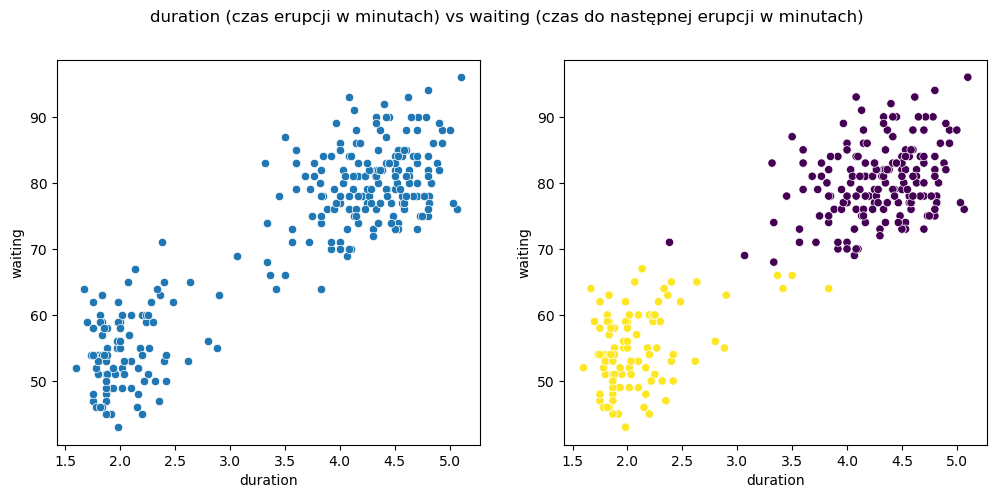

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('duration (czas erupcji w minutach) vs waiting (czas do następnej erupcji w minutach)')

sns.scatterplot(x='duration', y='waiting', data=df, ax=ax[0])
sns.scatterplot(x='duration', y='waiting', c=df['kind'], data=df, ax=ax[1])

plt.show()

## K-Means

### K-Means to algorytm, który dzieli dane na k określonych grup. Przypisuje punkty do określonej klasy na podstawie centroidów. Centroidy na początku są losowane i przypisane do takiego samego położenia co wylosowany punkt. Następnie punkty są przypisywane do określonej grupy ze względu na najbliższy centroid, a odległość obliczana jest za pomocą odległości euklidesowej. Następnie algorytm oblicza nowe położenie centroidów na podstawie średniej arytmetycznej wszystkich punktów w klastrze. Algorytm kontynuuje proces obliczania przynależności punktów do zmieniających się centroidów do momentu, gdy położenie centroidów przestaje ulegać zmianie. K-Means jest algorytmem nienadzorowanych, co znaczy, że nie potrzebuje etykiet y tak jak inne algorytmy do nauki rozpoznania punktów, bo korzysta z wcześniej opisanej metody, więc y_train nie jest potrzebne, a co najwyżej można sprawdzić skuteczność algorytmu za pomocą etykiet.

In [16]:
X = df.drop('kind', axis=1)
y = df['kind']

In [17]:
# https://medium.com/@hafsasultana0106/exploring-clustering-techniques-a-step-by-step-guide-to-k-means-with-scikit-learn-a671739f31fa
model_kmeans = KMeans(n_clusters=2, random_state=42)
model_kmeans.fit(X)

# https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
# lub model_kmeans.labels_
y_pred_kmeans = model_kmeans.predict(X)

### Tak jak widać na wykresach wyniki klastrowania jakie dał k-means są takie same wyniki jak oryginalne wartości, zatem klastrowanie przeszło pomyślnie.

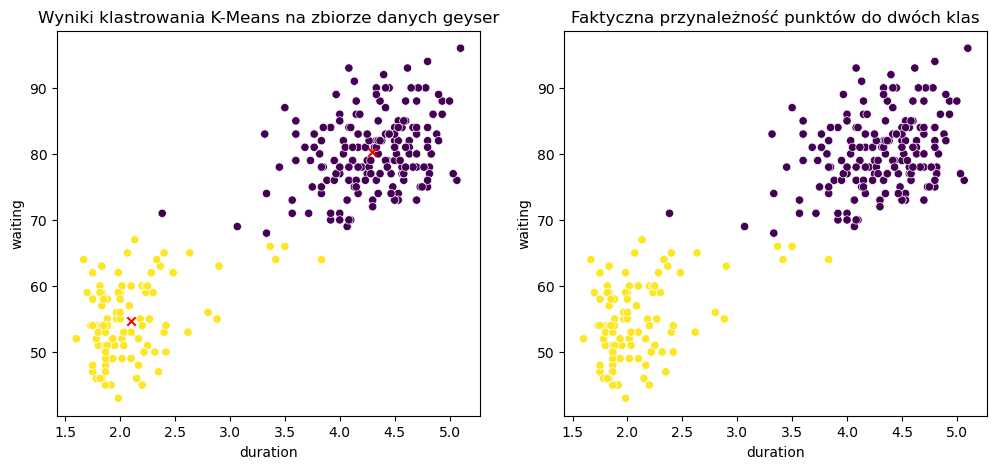

In [18]:
centers = model_kmeans.cluster_centers_

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x='duration', y='waiting', c=y_pred_kmeans, data=df, ax=ax[0])
ax[0].scatter(centers[:, 0], centers[:, 1], c='red', marker='x')
ax[0].set_title('Wyniki klastrowania K-Means na zbiorze danych geyser')

sns.scatterplot(x='duration', y='waiting', c=df['kind'], data=df, ax=ax[1])
ax[1].set_title('Faktyczna przynależność punktów do dwóch klas')

plt.show()

## Metoda Elbow

### Metoda Elbow ma na celu określenia jakie k w K-Means (ile jest grup), gdy nie wiadomo jakie k jest faktycznie. K-Means jest użytecznym algorytmem, ponieważ nie potrzebuje posiadać etykiet, aby przypisać dane do określonych grup. Jeśli nie wiadomo ile jest grup to jest to dobra metoda na ustalenie tego. Metoda Elbow korzysta z wartości inertia, która jest sumą punktów i sumą cech, gdzie dodaje się kwadrat różnicy pomiędzy określonym punktem, a najbliższym centroidem dla tego punktu. Dzięki wartości inertia sprawdza się klastry. Jeśli wartość jest bardzo duża to znaczy, że punkty są daleko od swoich centroidów - klastry są rozmyte, słabo określone. Jeśli wartość jest mała to klastry ułożone są blisko centroidów.

In [19]:
kmeans_model_inertias = []

for k in range(1, 11):
    model_kmeans_k = KMeans(n_clusters=k, random_state=42)
    model_kmeans_k.fit(X)

    kmeans_model_inertias.append(model_kmeans_k.inertia_)

### Wykres pokazuje, że k powinno wynosić 2 co jest zgodne z prawdą.

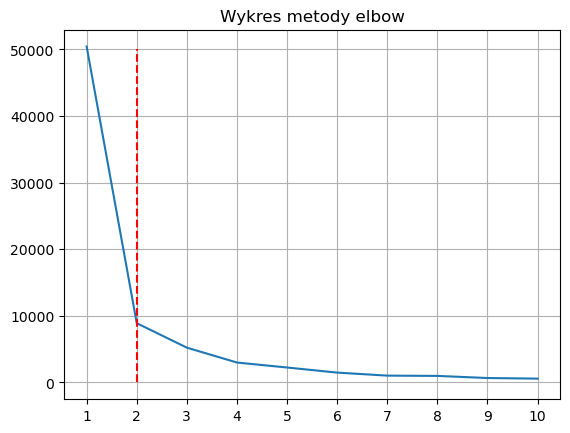

In [20]:
# https://stackoverflow.com/questions/51762514/find-the-elbow-point-on-an-optimization-curve-with-python
knee_locator = KneeLocator(range(1, 11), kmeans_model_inertias, curve='convex', direction='decreasing')

plt.plot(range(1, 11), kmeans_model_inertias)
plt.vlines(knee_locator.knee, 0, 50000, linestyles='dashed', color='red')
plt.title('Wykres metody elbow')
plt.xticks(range(1, 11))
plt.grid()
plt.show()

In [21]:
for k in range(0, 10):
    print(f'Wynik inertias dla modelu k = {k+1} wynosi: {kmeans_model_inertias[k]}')

Wynik inertias dla modelu k = 1 wynosi: 50440.15702526102
Wynik inertias dla modelu k = 2 wynosi: 8901.76872094721
Wynik inertias dla modelu k = 3 wynosi: 5229.058840018192
Wynik inertias dla modelu k = 4 wynosi: 2993.5940055361357
Wynik inertias dla modelu k = 5 wynosi: 2247.3513439552053
Wynik inertias dla modelu k = 6 wynosi: 1482.9582898108542
Wynik inertias dla modelu k = 7 wynosi: 1029.7289384204523
Wynik inertias dla modelu k = 8 wynosi: 986.4703961866048
Wynik inertias dla modelu k = 9 wynosi: 667.9017889730269
Wynik inertias dla modelu k = 10 wynosi: 578.2639557783233


## Wynik Silhouette

### Silhouette score pokazuje jak dobrze rozdzielone są klastry. Im wyższy wynik (im bliżej 1) tym lepiej są one oddzielone, a im wartość niższa tym gorzej.

In [22]:
# https://www.geeksforgeeks.org/machine-learning/what-is-silhouette-score/
kmeans_model_silhouette_scores = []

for k in range(2, 11):
    model_kmeans_k = KMeans(n_clusters=k, random_state=42)
    model_kmeans_k.fit(X)

    y_pred_kmeans_k = model_kmeans_k.predict(X)

    kmeans_model_silhouette_scores.append(silhouette_score(X, y_pred_kmeans_k))

### Wykres daje najwyższą wartość dla k = 2, co w tym wypadku jest zgodne z prawdą.

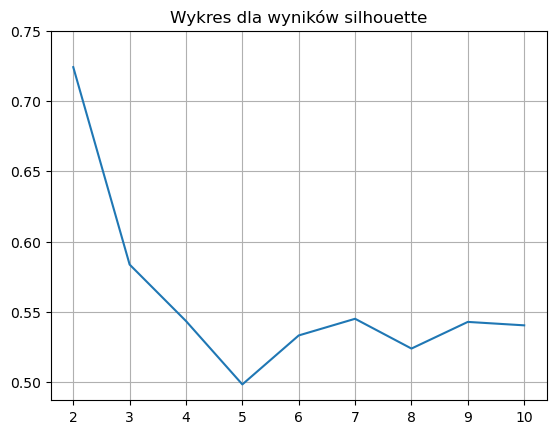

In [23]:
plt.plot(range(2, 11), kmeans_model_silhouette_scores)
plt.title('Wykres dla wyników silhouette')
plt.yticks(np.arange(0.5, 0.76, 0.05))
plt.grid()
plt.show()

In [24]:
for k in range(0, 9):
    print(f'Wynik silhouette dla modelu k = {k+2} wynosi: {kmeans_model_silhouette_scores[k]}')

Wynik silhouette dla modelu k = 2 wynosi: 0.724054851995858
Wynik silhouette dla modelu k = 3 wynosi: 0.583617622775959
Wynik silhouette dla modelu k = 4 wynosi: 0.5434232196327469
Wynik silhouette dla modelu k = 5 wynosi: 0.4983428132299225
Wynik silhouette dla modelu k = 6 wynosi: 0.5331793518020691
Wynik silhouette dla modelu k = 7 wynosi: 0.5450368394997572
Wynik silhouette dla modelu k = 8 wynosi: 0.5238475618598685
Wynik silhouette dla modelu k = 9 wynosi: 0.5428094887033891
Wynik silhouette dla modelu k = 10 wynosi: 0.5403700029701033


# Analiza zbioru danych: penguins

In [25]:
df2 = sns.load_dataset('penguins')

## Zapoznanie ze zbiorem danych

In [26]:
df2.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [27]:
df2.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [28]:
df2.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [29]:
df2.shape

(344, 7)

In [30]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [31]:
df2.dtypes

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

In [32]:
df2.columns.tolist()

['species',
 'island',
 'bill_length_mm',
 'bill_depth_mm',
 'flipper_length_mm',
 'body_mass_g',
 'sex']

In [33]:
df2['species'].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [34]:
df2['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

## Zmiana wartości w kolumnie species na numeryczne

In [35]:
le2 = LabelEncoder()
df2['species'] = le2.fit_transform(df2['species'])

In [36]:
df2.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,Torgersen,39.1,18.7,181.0,3750.0,Male
1,0,Torgersen,39.5,17.4,186.0,3800.0,Female
2,0,Torgersen,40.3,18.0,195.0,3250.0,Female
3,0,Torgersen,NaN,NaN,NaN,NaN,NaN
4,0,Torgersen,36.7,19.3,193.0,3450.0,Female
5,0,Torgersen,39.3,20.6,190.0,3650.0,Male
6,0,Torgersen,38.9,17.8,181.0,3625.0,Female
7,0,Torgersen,39.2,19.6,195.0,4675.0,Male
8,0,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,0,Torgersen,42.0,20.2,190.0,4250.0,NaN


## Usunięcie brakujących wartości

In [37]:
df2 = df2.dropna()

In [38]:
df2.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [39]:
df2['species'].value_counts()

species
0    146
2    119
1     68
Name: count, dtype: int64

## K-Means

In [40]:
X = df2.drop(['species', 'island', 'sex'], axis=1)
y = df2['species']

### Użycie K-Means na przeskalowanych danych przy yżyciu dwóch metod: StandardScaler() oraz MinMaxScaler()

In [41]:
X_standard_scaled = X.copy()
X_min_max_scaled = X.copy()

columns_to_standardize = X.columns.tolist()

scaler_standard = StandardScaler()
X_standard_scaled[columns_to_standardize] = scaler_standard.fit_transform(X[columns_to_standardize])

scaler_min_max = MinMaxScaler()
X_min_max_scaled[columns_to_standardize] = scaler_min_max.fit_transform(X[columns_to_standardize])

In [42]:
model_kmeans_standard_scaler = KMeans(n_clusters=3, random_state=42)
model_kmeans_standard_scaler.fit(X_standard_scaled)

KMeans(n_clusters=3, random_state=42)

In [43]:
y_pred_kmeans_standard_scaled = model_kmeans_standard_scaler.predict(X_standard_scaled)

print('Macierz pomyłek (Confusion Matrix):\n', confusion_matrix(y, y_pred_kmeans_standard_scaled))

Macierz pomyłek (Confusion Matrix):
 [[124   0  22]
 [  5   0  63]
 [  0 119   0]]


In [44]:
model_kmeans_min_max_scaler = KMeans(n_clusters=3, random_state=42)
model_kmeans_min_max_scaler.fit(X_min_max_scaled)

KMeans(n_clusters=3, random_state=42)

In [45]:
y_pred_kmeans_min_max_scaled = model_kmeans_min_max_scaler.predict(X_min_max_scaled)

print('Macierz pomyłek (Confusion Matrix):\n', confusion_matrix(y, y_pred_kmeans_min_max_scaled))

Macierz pomyłek (Confusion Matrix):
 [[117   0  29]
 [  8   0  60]
 [  0 119   0]]


## Metoda Elbow

In [46]:
kmeans_model_inertias_standardscaler = []

for k in range(1, 11):
    model_kmeans_k = KMeans(n_clusters=k, random_state=42)
    model_kmeans_k.fit(X_standard_scaled)

    kmeans_model_inertias_standardscaler.append(model_kmeans_k.inertia_)

In [47]:
kmeans_model_inertias_min_max_scaler = []

for k in range(1, 11):
    model_kmeans_k = KMeans(n_clusters=k, random_state=42)
    model_kmeans_k.fit(X_min_max_scaled)

    kmeans_model_inertias_min_max_scaler.append(model_kmeans_k.inertia_)

### Metoda Elbow dała poprawne wyniki, bo wskazuje k = 3, co jest zgodne z prawdą.

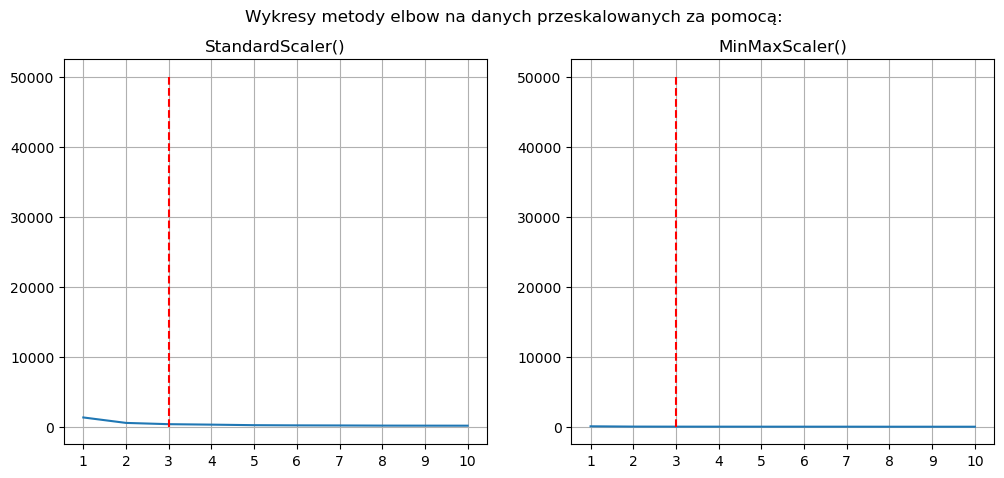

In [48]:
knee_locator_standardscaler = KneeLocator(range(1, 11), kmeans_model_inertias_standardscaler, curve='convex', direction='decreasing')
knee_locator_min_max_scaler = KneeLocator(range(1, 11), kmeans_model_inertias_min_max_scaler, curve='convex', direction='decreasing')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Wykresy metody elbow na danych przeskalowanych za pomocą:')

ax[0].plot(range(1, 11), kmeans_model_inertias_standardscaler)
ax[0].vlines(knee_locator_standardscaler.knee, 0, 50000, linestyles='dashed', color='red')
ax[0].set_title('StandardScaler()')
ax[0].set_xticks(range(1, 11))
ax[0].grid()

ax[1].plot(range(1, 11), kmeans_model_inertias_min_max_scaler)
ax[1].vlines(knee_locator_min_max_scaler.knee, 0, 50000, linestyles='dashed', color='red')
ax[1].set_title('MinMaxScaler()')
ax[1].set_xticks(range(1, 11))
ax[1].grid()

plt.show()

In [49]:
scaler_methods = ['StandardScaler()', 'MinMaxScaler()']
scaler_inertias_results = [kmeans_model_inertias_standardscaler, kmeans_model_inertias_min_max_scaler]

for idx, scaler_method in enumerate(scaler_methods):
    for k in range(0, 10):
        print(f'Wynik inertias dla modelu k = {k+1} w których dane przeskalowano przy pomocy {scaler_method} wynosi: {scaler_inertias_results[idx][k]}')
    print()

Wynik inertias dla modelu k = 1 w których dane przeskalowano przy pomocy StandardScaler() wynosi: 1332.0
Wynik inertias dla modelu k = 2 w których dane przeskalowano przy pomocy StandardScaler() wynosi: 552.6710215353656
Wynik inertias dla modelu k = 3 w których dane przeskalowano przy pomocy StandardScaler() wynosi: 370.766143513507
Wynik inertias dla modelu k = 4 w których dane przeskalowano przy pomocy StandardScaler() wynosi: 305.4341634282505
Wynik inertias dla modelu k = 5 w których dane przeskalowano przy pomocy StandardScaler() wynosi: 228.69567588434245
Wynik inertias dla modelu k = 6 w których dane przeskalowano przy pomocy StandardScaler() wynosi: 200.6032633799271
Wynik inertias dla modelu k = 7 w których dane przeskalowano przy pomocy StandardScaler() wynosi: 187.33324097450912
Wynik inertias dla modelu k = 8 w których dane przeskalowano przy pomocy StandardScaler() wynosi: 167.13924410400918
Wynik inertias dla modelu k = 9 w których dane przeskalowano przy pomocy Standard

## Wynik Silhouette

In [50]:
kmeans_model_silhouette_scores_standardscaler = []

for k in range(2, 11):
    model_kmeans_k = KMeans(n_clusters=k, random_state=42)
    model_kmeans_k.fit(X_standard_scaled)

    y_pred_kmeans_k = model_kmeans_k.predict(X_standard_scaled)

    kmeans_model_silhouette_scores_standardscaler.append(silhouette_score(X_standard_scaled, y_pred_kmeans_k))

In [51]:
kmeans_model_silhouette_scores_min_maxscaler = []

for k in range(2, 11):
    model_kmeans_k = KMeans(n_clusters=k, random_state=42)
    model_kmeans_k.fit(X_min_max_scaled)

    y_pred_kmeans_k = model_kmeans_k.predict(X_min_max_scaled)

    kmeans_model_silhouette_scores_min_maxscaler.append(silhouette_score(X_min_max_scaled, y_pred_kmeans_k))

### Wyniki dla Silhouette nie są najwyższe dla k = 3, a dla k = 2 co w tym przypadku odbiega od rzeczywistości. Metoda Elbow w tym przypadku lepiej określiła jaka powinna być liczba klastrów.

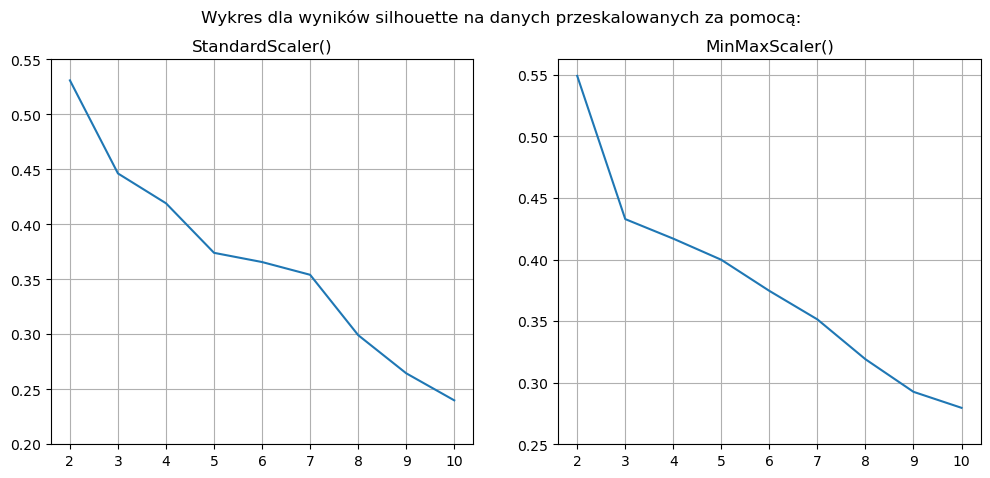

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Wykres dla wyników silhouette na danych przeskalowanych za pomocą:')

ax[0].plot(range(2, 11), kmeans_model_silhouette_scores_standardscaler)
ax[0].set_title('StandardScaler()')
ax[0].set_yticks(np.arange(0.2, 0.56, 0.05))
ax[0].grid()

ax[1].plot(range(2, 11), kmeans_model_silhouette_scores_min_maxscaler)
ax[1].set_title('MinMaxScaler()')
ax[1].set_yticks(np.arange(0.25, 0.56, 0.05))
ax[1].grid()

plt.show()

In [53]:
scaler_methods = ['StandardScaler()', 'MinMaxScaler()']
scaler_silhouette_results = [kmeans_model_silhouette_scores_standardscaler, kmeans_model_silhouette_scores_min_maxscaler]

for idx, scaler_method in enumerate(scaler_methods):
    for k in range(0, 9):
        print(f'Wynik inertias dla modelu k = {k+1} w których dane przeskalowano przy pomocy {scaler_method} wynosi: {scaler_silhouette_results[idx][k]}')
    print()

Wynik inertias dla modelu k = 1 w których dane przeskalowano przy pomocy StandardScaler() wynosi: 0.5308173701641073
Wynik inertias dla modelu k = 2 w których dane przeskalowano przy pomocy StandardScaler() wynosi: 0.446192544665462
Wynik inertias dla modelu k = 3 w których dane przeskalowano przy pomocy StandardScaler() wynosi: 0.41908032197402917
Wynik inertias dla modelu k = 4 w których dane przeskalowano przy pomocy StandardScaler() wynosi: 0.374042484653286
Wynik inertias dla modelu k = 5 w których dane przeskalowano przy pomocy StandardScaler() wynosi: 0.3656638618347054
Wynik inertias dla modelu k = 6 w których dane przeskalowano przy pomocy StandardScaler() wynosi: 0.3540779077639277
Wynik inertias dla modelu k = 7 w których dane przeskalowano przy pomocy StandardScaler() wynosi: 0.29924043273609774
Wynik inertias dla modelu k = 8 w których dane przeskalowano przy pomocy StandardScaler() wynosi: 0.26454825146561617
Wynik inertias dla modelu k = 9 w których dane przeskalowano pr

## PCA

### PCA pozwala na połączenie kilku cech w określoną ich ilość. W tym wypadku 4 cechy przekształcane są w 2 cechy. PCA znajduje PC1, gdzie chmura punktów jest najbardziej rozciągnięta oraz PC2 - drugie co do wielkości rozciągnięcie w kierunku prostopadłym. Dzięki tej technice można przedstawić, np. K-Means na wykresie 2d mimo, że ilość cech wynosi 4, a nie 2.

In [54]:
pca_standard = PCA(n_components=2)
pca_min_max = PCA(n_components=2)

X_standard_scaled_pca = pca_standard.fit_transform(X_standard_scaled)
X_min_max_scaled_pca = pca_min_max.fit_transform(X_min_max_scaled)

centers_standardscaler = pca_standard.transform(model_kmeans_standard_scaler.cluster_centers_)
centers_min_max = pca_min_max.transform(model_kmeans_min_max_scaler.cluster_centers_)

### Tak jak można odczytać z poniższych danych, większość informacji po użyciu PCA zostało zachowanych.

In [55]:
print('Wariancja dla StandardScaler():')
print(f'Wariancja dla PC1 wynosi: {pca_standard.explained_variance_ratio_[0]*100:.2f}%.')
print(f'Wariancja dla PC2 wynosi: {pca_standard.explained_variance_ratio_[1]*100:.2f}%.')
print(f'Łączna ilość zachowanych danych wynosi: {(pca_standard.explained_variance_ratio_[0] + pca_standard.explained_variance_ratio_[1])*100:.2f}%.\n')

print('Wariancja dla MinMaxScaler():')
print(f'Wariancja dla PC1 wynosi: {pca_min_max.explained_variance_ratio_[0]*100:.2f}%.')
print(f'Wariancja dla PC2 wynosi: {pca_min_max.explained_variance_ratio_[1]*100:.2f}%.')
print(f'Łączna ilość zachowanych danych wynosi: {(pca_min_max.explained_variance_ratio_[0] + pca_min_max.explained_variance_ratio_[1])*100:.2f}%.')

Wariancja dla StandardScaler():
Wariancja dla PC1 wynosi: 68.63%.
Wariancja dla PC2 wynosi: 19.45%.
Łączna ilość zachowanych danych wynosi: 88.09%.

Wariancja dla MinMaxScaler():
Wariancja dla PC1 wynosi: 69.63%.
Wariancja dla PC2 wynosi: 19.17%.
Łączna ilość zachowanych danych wynosi: 88.79%.


### Wykresy pokazują w jaki sposób algorytm K-Means przypisał punkty do których cech. Tak jak widać na wykresach punkty nachodzące na siebie z innych klas mogą być źle przypisane, ale ogólnie algorytm dość dobrze radzi sobie z ustaleniem przynależności danego punktu do odpowiedniej klasy. Żółte punkty zostały przypisane perfekcyjnie dla obu przypadków, zaś część punktów z pozostałych dwóch klas algorytm źle przypisuje. Klasy były ze sobą zamienione dla (klasa nr. 2 z nr. 3), więc dla warto naprawić to dla lepszej spójności wyników na wykresie oraz metryk - aby dawały poprawne wyniki.

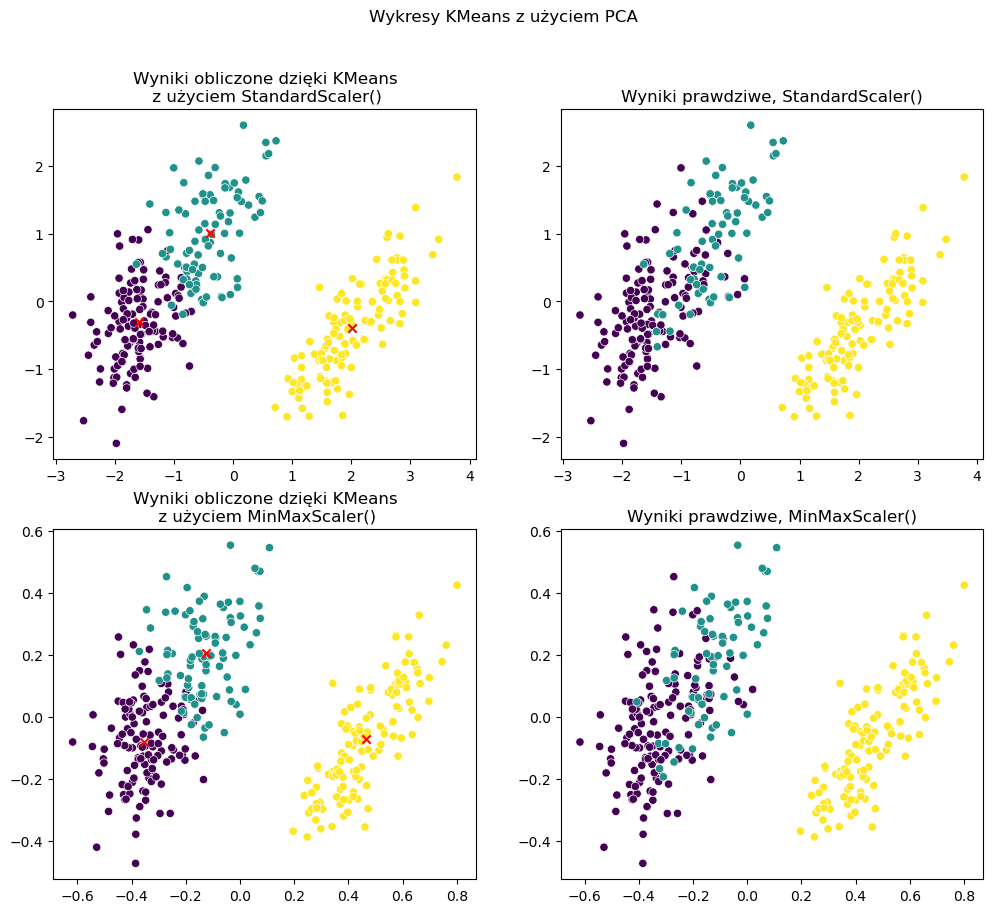

In [56]:
# https://stackoverflow.com/questions/36329412/map-list-from-dictionaries
change_color_class = {0: 0, 1:2, 2:1}
color_repair_y_pred_kmeans_standard_scaled = list(map(change_color_class.get, y_pred_kmeans_standard_scaled))
color_repair_y_pred_kmeans_min_max_scaled = list(map(change_color_class.get, y_pred_kmeans_min_max_scaled))

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Wykresy KMeans z użyciem PCA')

sns.scatterplot(x=X_standard_scaled_pca[:, 0], y=X_standard_scaled_pca[:, 1], c=color_repair_y_pred_kmeans_standard_scaled, ax=ax[0, 0])
ax[0, 0].scatter(centers_standardscaler[:, 0], centers_standardscaler[:, 1], c='red', marker='x')
ax[0, 0].set_title('Wyniki obliczone dzięki KMeans\n z użyciem StandardScaler()')

sns.scatterplot(x=X_standard_scaled_pca[:, 0], y=X_standard_scaled_pca[:, 1], c=y, ax=ax[0, 1])
ax[0, 1].set_title('Wyniki prawdziwe, StandardScaler()')

sns.scatterplot(x=X_min_max_scaled_pca[:, 0], y=X_min_max_scaled_pca[:, 1], c=color_repair_y_pred_kmeans_min_max_scaled, ax=ax[1, 0])
ax[1, 0].scatter(centers_min_max[:, 0], centers_min_max[:, 1], c='red', marker='x')
ax[1, 0].set_title('Wyniki obliczone dzięki KMeans\n z użyciem MinMaxScaler()')

sns.scatterplot(x=X_min_max_scaled_pca[:, 0], y=X_min_max_scaled_pca[:, 1], c=y, ax=ax[1, 1])
ax[1, 1].set_title('Wyniki prawdziwe, MinMaxScaler()')

plt.show()

### Accuracy score udowadnia, że skuteczność K-Means jest dość duża (StandardScaler(): 92% > MinMaxScaler(): 89%). Macierz pomyłek pozwala zaobserwować, gdzie punkty zostały odpowiednio przypisane do odpowiedniej klasy, a gdzie nie. Tak jak było widać na wykresie dla klasy żółtej wyniki są perfekcyjne, ale dla pozostałych dwóch algorytm może się mylić, chociaż skuteczność jest dość wysoka. Odrobinę lepsze wyniki dało użycie StandardScaler(): 92% niż użycie MinMaxScaler(): 89%.

In [57]:
print('Dokładność (Accuracy Score) dla StandardScaler():', accuracy_score(y, color_repair_y_pred_kmeans_standard_scaled))
print('\nMacierz pomyłek (Confusion Matrix) dla StandardScaler():\n', confusion_matrix(y, color_repair_y_pred_kmeans_standard_scaled))
print('\nRaport dla StandardScaler():\n', classification_report(y, color_repair_y_pred_kmeans_standard_scaled))

print('Dokładność (Accuracy Score) dla MinMaxScaler():', accuracy_score(y, color_repair_y_pred_kmeans_min_max_scaled))
print('\nMacierz pomyłek (Confusion Matrix) dla MinMaxScaler():\n', confusion_matrix(y, color_repair_y_pred_kmeans_min_max_scaled))
print('\nRaport dla MinMaxScaler():\n', classification_report(y, color_repair_y_pred_kmeans_min_max_scaled))

Dokładność (Accuracy Score) dla StandardScaler(): 0.918918918918919

Macierz pomyłek (Confusion Matrix) dla StandardScaler():
 [[124  22   0]
 [  5  63   0]
 [  0   0 119]]

Raport dla StandardScaler():
               precision    recall  f1-score   support

           0       0.96      0.85      0.90       146
           1       0.74      0.93      0.82        68
           2       1.00      1.00      1.00       119

    accuracy                           0.92       333
   macro avg       0.90      0.93      0.91       333
weighted avg       0.93      0.92      0.92       333

Dokładność (Accuracy Score) dla MinMaxScaler(): 0.8888888888888888

Macierz pomyłek (Confusion Matrix) dla MinMaxScaler():
 [[117  29   0]
 [  8  60   0]
 [  0   0 119]]

Raport dla MinMaxScaler():
               precision    recall  f1-score   support

           0       0.94      0.80      0.86       146
           1       0.67      0.88      0.76        68
           2       1.00      1.00      1.00       119